In [1]:
import os
os.chdir("..")

In [2]:
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py
from src.inference.inference import SegInference
import torch
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import os 
os.chdir("/nfshome/narjis/")

In [237]:
hdf5_path = "EV_brightfield.hdf5"
idx = 0
with h5py.File(hdf5_path, "r") as f:
    image_dataset_size = f["image_patches"].shape[0]
    img = f["image_patches"][idx]
    mask = f["mask_patches"][idx]

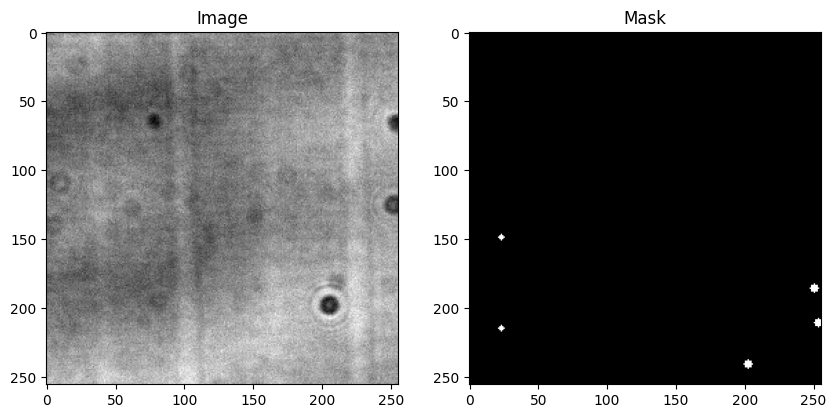

In [230]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img[0], cmap="gray")
ax[0].set_title("Image")
ax[1].imshow(mask[0], cmap="gray")
ax[1].set_title("Mask")
plt.show()

In [304]:
def to_8bit(image):
    """
    Convert a 16-bit image to an 8-bit image.
    """
    # Normalize the image to the range [0, 255]
    min_val = image.min()
    max_val = image.max()
    # normalized_image = (image / image.max()) * 255.0
    normalized_image = (image - min_val) / (max_val - min_val) * 255.0
    # Clip values to the range [0, 255]
    normalized_image = np.clip(normalized_image, 0, 255)
    # Convert to uint8
    return normalized_image.astype(np.uint8)

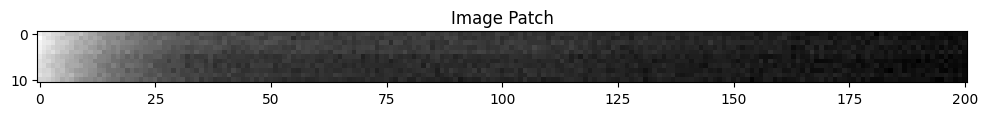

In [234]:
from skimage import measure
import numpy as np

# Option to choose specific index or the region with the biggest area
choose_biggest_area = False  # Set to False to choose a specific index
idx = 4  # Only used if choose_biggest_area is False

# Label connected regions in the mask
labeled_mask = measure.label(mask[0])
normalized_img = img
# Get properties of labeled regions
regions = measure.regionprops(labeled_mask)

if regions:
    if choose_biggest_area:
        # Find the region with the biggest area
        region = max(regions, key=lambda r: r.area)
    else:
        # Select the region by index
        region = regions[idx]
    # Get bounding box of the region
    min_row, min_col, max_row, max_col = region.bbox

    # Extract a small image patch from img using the bounding box
    tolerance = 2

    image_patch = normalized_img[:, max(0, min_row-tolerance):min(img.shape[1], max_row+tolerance), max(0, min_col-tolerance):min(img.shape[2], max_col+tolerance)]
else:
    print("No labeled regions found in the mask.")

avg_img = np.mean(image_patch, axis=1)
avg_img = avg_img.transpose(1,0)
# Display the image patch
fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(avg_img, cmap="gray")
ax.set_title("Image Patch")
plt.show()

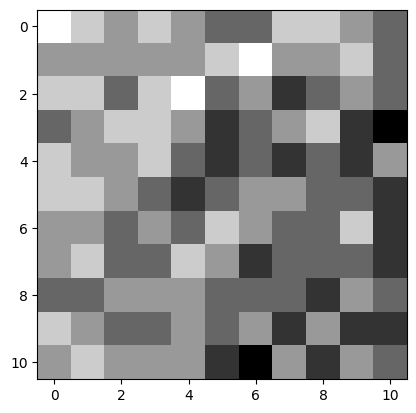

In [8]:
# plt.imshow(to_8bit(image_patch[0]), cmap="gray")
plt.imshow(image_patch[10], cmap="gray")
plt.show()

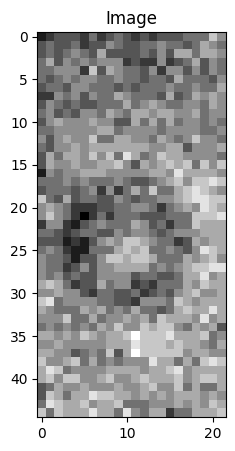

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.imshow(to_8bit(img[0,85:130,0:22]), cmap="gray")
ax.set_title("Image")
plt.show()

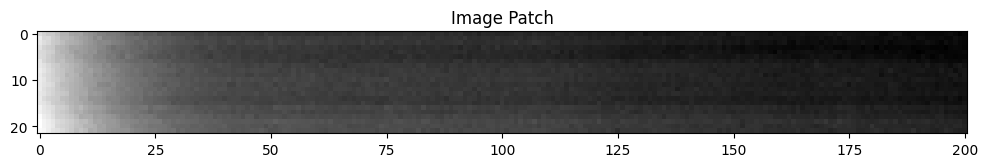

In [10]:
ev_p = img[:,85:130,0:22]
ev_p = np.mean(ev_p, axis=1)
ev_p = ev_p.transpose(1,0)
# Display the image patch
fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(ev_p, cmap="gray")
ax.set_title("Image Patch")
plt.show()

In [11]:
def process_hdf5_images(hdf5_path):
    """
    Open the HDF5 file, load all images, extract regions, average over the x-axis,
    transpose to (1, 0), resize the 0-axis to 16 by padding equally at the top and bottom,
    and store everything in one array.

    Parameters:
        hdf5_path (str): Path to the HDF5 file.

    Returns:
        numpy.ndarray: Processed array containing all resized image regions.
    """
    with h5py.File(hdf5_path, "r") as f:
        # Load all images
        images = f["image_patches"][:]
        masks = f["mask_patches"][:]
        
        processed_images = []

        for img, mask in zip(images, masks):
            # Normalize the image
            normalized_img = img

            # Label connected regions in the mask
            labeled_mask = measure.label(mask[0])

            # Get properties of labeled regions
            regions = measure.regionprops(labeled_mask)

            for region in regions:
                # Get bounding box of the region
                min_row, min_col, max_row, max_col = region.bbox

                # Extract a small image patch from img using the bounding box
                tolerance = 2
                image_patch = normalized_img[:, 
                                             max(0, min_row - tolerance):min(img.shape[1], max_row + tolerance), 
                                             max(0, min_col - tolerance):min(img.shape[2], max_col + tolerance)]

                # Average over the x-axis
                avg_img = np.mean(image_patch, axis=1)

                # Transpose to (1, 0)
                avg_img = avg_img.transpose(1, 0)

                # Resize the 0-axis to 16 by padding equally at the top and bottom
                if avg_img.shape[0] < 16:
                    total_padding = 16 - avg_img.shape[0]
                    padding_top = total_padding // 2
                    padding_bottom = total_padding - padding_top
                    padding = np.tile(avg_img[0], (padding_top, 1))
                    avg_img = np.vstack((padding, avg_img))
                    padding = np.tile(avg_img[-1], (padding_bottom, 1))
                    avg_img = np.vstack((avg_img, padding))
                elif avg_img.shape[0] > 16:
                    avg_img = avg_img[:16]

                # Add to the processed images list
                processed_images.append(avg_img)

        # Combine all processed images into one array
        processed_array = np.array(processed_images)
        return processed_array

In [12]:
ev_particles=process_hdf5_images(hdf5_path)

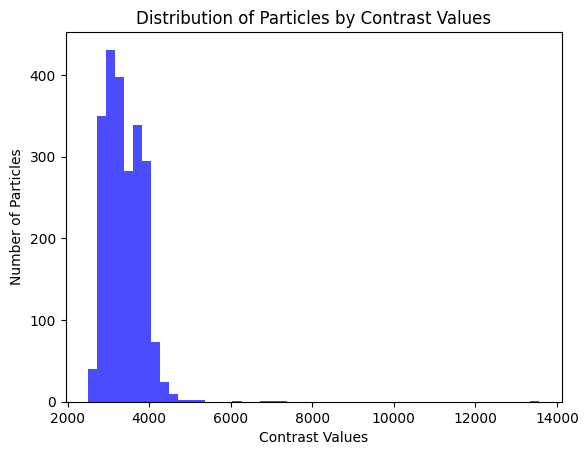

In [13]:
# Calculate contrast for each particle in ev_particles
contrast_values = [np.max(particle) - np.min(particle) for particle in ev_particles]

# Flatten the contrast values to create a single array
# flattened_contrast = np.concatenate(contrast_values)

# Plot the histogram
plt.hist(contrast_values, bins=50, color='blue', alpha=0.7)
plt.xlabel("Contrast Values")
plt.ylabel("Number of Particles")
plt.title("Distribution of Particles by Contrast Values")
plt.show()

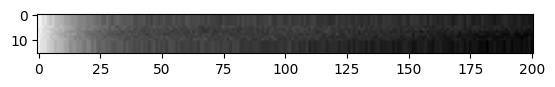

In [14]:
plt.imshow(ev_particles[2], cmap="gray")

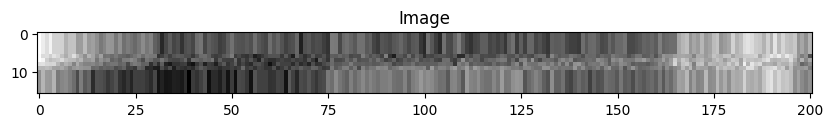

In [15]:
hdf5_path = "Downloads/brightfield_particles.hdf5"
idx = 3
with h5py.File(hdf5_path, "r") as f:
    image_dataset_size = f["data"].shape[0]
    img_ = f["data"][idx]
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.imshow(img_, cmap="gray")
ax.set_title("Image")
plt.show()

In [16]:
os.getcwd()
os.chdir("/nfshome/narjis/workspace/iscat/")

In [333]:
DEVICE = "cuda:0"
experiment_path = "/nfshome/narjis/workspace/iscat/experiments/runs/U_Net_Brightfield_EV_seg_2025-05-13_17-17-22"
seginf = SegInference(experiment_path,DEVICE)
model = seginf.model

In [75]:
import os 
os.chdir("/nfshome/narjis/")

In [334]:
from src.data_processing.dataset import iScatDataset
h5py_path = "EV_brightfield.hdf5"
dataset = iScatDataset(h5py_path,[0],normalize="zscore",chunk_size=32,multi_class=False,apply_augmentation=False)

In [345]:
for i in range(20,250):
    idx = i
    img, mask = dataset[idx][0], dataset[idx][1]
    def predict(model, image):
        """
        Use the model to predict the mask for a given image.

        Parameters:
            model (torch.nn.Module): The trained model for prediction.
            image (numpy.ndarray): The input image to predict the mask for.

        Returns:
            numpy.ndarray: The predicted mask.
        """
        model.eval()  # Set the model to evaluation mode
        with torch.no_grad():  # Disable gradient computation
            # Convert the image to a PyTorch tensor and add batch and channel dimensions
            image_tensor = image.float().clone().unsqueeze(0).to(DEVICE)
            # Perform the prediction
            predicted_mask = model(image_tensor).detach()
            predicted_mask = torch.sigmoid(predicted_mask).squeeze().cpu().numpy()
            # predicted_mask = predicted_mask.squeeze().cpu().numpy()
            # print(predicted_mask)
            # Convert the predicted mask back to a numpy array
            predicted_mask = predicted_mask > 0.5  # Convert the predicted mask to binary (0 or 1)
            predicted_mask = predicted_mask.astype(np.uint8)
            # print(predicted_mask)
            # Convert the predicted mask to binary (0 or 1)  
            # Resize the predicted mask to match the original image size
        return predicted_mask
    predicted_mask = predict(model, img)
    condition = (predicted_mask == mask.numpy().astype(np.uint8))
    if (predicted_mask[condition] == 1).any():
        break
    # print(predicted_mask)

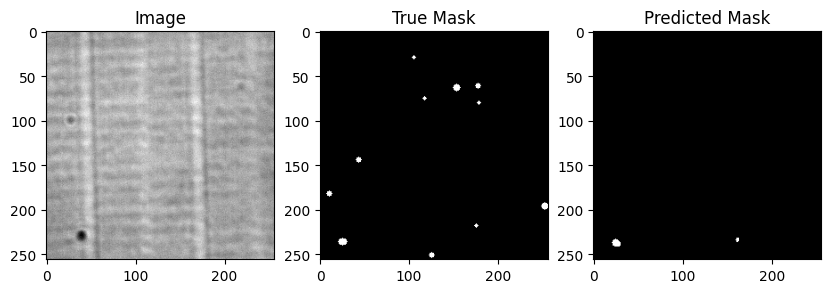

In [346]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(img[0], cmap="gray")
ax[0].set_title("Image")
ax[1].imshow(mask, cmap="gray")
ax[1].set_title("True Mask")
ax[2].imshow(predicted_mask, cmap="gray")
ax[2].set_title("Predicted Mask")
plt.show()

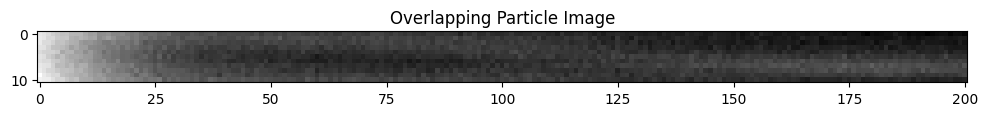

In [348]:
def get_overlapping_particle(img, gt_mask, pred_mask):
    """
    Extract the overlapping particle image between the ground truth mask and the predicted mask.

    Parameters:
        img (numpy.ndarray): The original image.
        gt_mask (numpy.ndarray): The ground truth mask.
        pred_mask (numpy.ndarray): The predicted mask.

    Returns:
        numpy.ndarray: The extracted overlapping particle image.
    """
    # Label connected regions in the ground truth mask and predicted mask
    labeled_gt = measure.label(gt_mask)
    labeled_pred = measure.label(pred_mask)

    # Find overlapping regions
    overlapping_regions = []
    for region in measure.regionprops(labeled_gt):
        min_row, min_col, max_row, max_col = region.bbox
        gt_region = gt_mask[min_row:max_row, min_col:max_col]
        pred_region = pred_mask[min_row:max_row, min_col:max_col]
        
        # Check if there is overlap
        if np.any(gt_region & pred_region):
            overlapping_regions.append(region.bbox)

    # Extract the overlapping particle image
    if overlapping_regions:
        min_row, min_col, max_row, max_col = overlapping_regions[0]  # Assuming one overlapping region
        particle_image = img[:, min_row:max_row, min_col:max_col]
        return particle_image,overlapping_regions
    else:
        print("No overlapping particles found.")
        return None

# Example usage
with h5py.File("EV_brightfield.hdf5", "r") as f:
    img_ = f["image_patches"][idx]
overlapping_particle,overlapping_regions = get_overlapping_particle(img_, mask.numpy().astype(np.uint8), predicted_mask)
if overlapping_particle is not None:
    fig, ax = plt.subplots(figsize=(12, 10))
    ax.imshow(np.mean(overlapping_particle, axis=1).transpose(1,0), cmap="gray")
    ax.set_title("Overlapping Particle Image")
    plt.show()

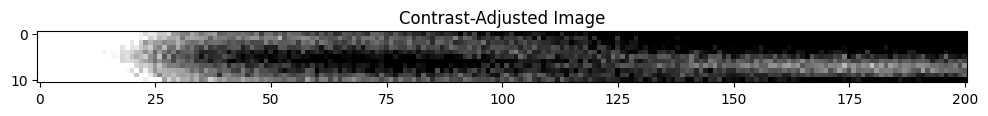

In [349]:
def adjust_contrast(image, lower_percentile=2, upper_percentile=98):
    """
    Adjust the contrast of a 16-bit image by stretching the intensity values 
    between the specified percentiles.

    Parameters:
        image (numpy.ndarray): The input 16-bit image.
        lower_percentile (float): The lower percentile for contrast adjustment.
        upper_percentile (float): The upper percentile for contrast adjustment.

    Returns:
        numpy.ndarray: The contrast-adjusted image.
    """
    # Compute the lower and upper intensity bounds
    lower_bound = np.percentile(image, lower_percentile)
    upper_bound = np.percentile(image, upper_percentile)

    # Clip the image to the bounds and normalize to the range [0, 65535]
    adjusted_image = np.clip(image, lower_bound, upper_bound)
    adjusted_image = ((adjusted_image - lower_bound) / (upper_bound - lower_bound) * 65535).astype(np.uint16)

    return adjusted_image

# Adjust the contrast of img_
adjusted_img = adjust_contrast(np.mean(overlapping_particle, axis=1).transpose(1,0), lower_percentile=20, upper_percentile=90)

# Display the adjusted image
fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(adjusted_img, cmap="gray")
ax.set_title("Contrast-Adjusted Image")
plt.show()


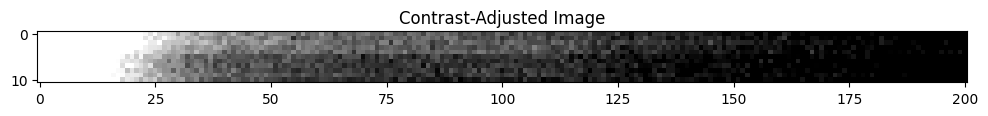

In [235]:
adjusted_img = adjust_contrast(np.mean(image_patch, axis=1).transpose(1,0), lower_percentile=20, upper_percentile=90)

# Display the adjusted image
fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(adjusted_img, cmap="gray")
ax.set_title("Contrast-Adjusted Image")
plt.show()

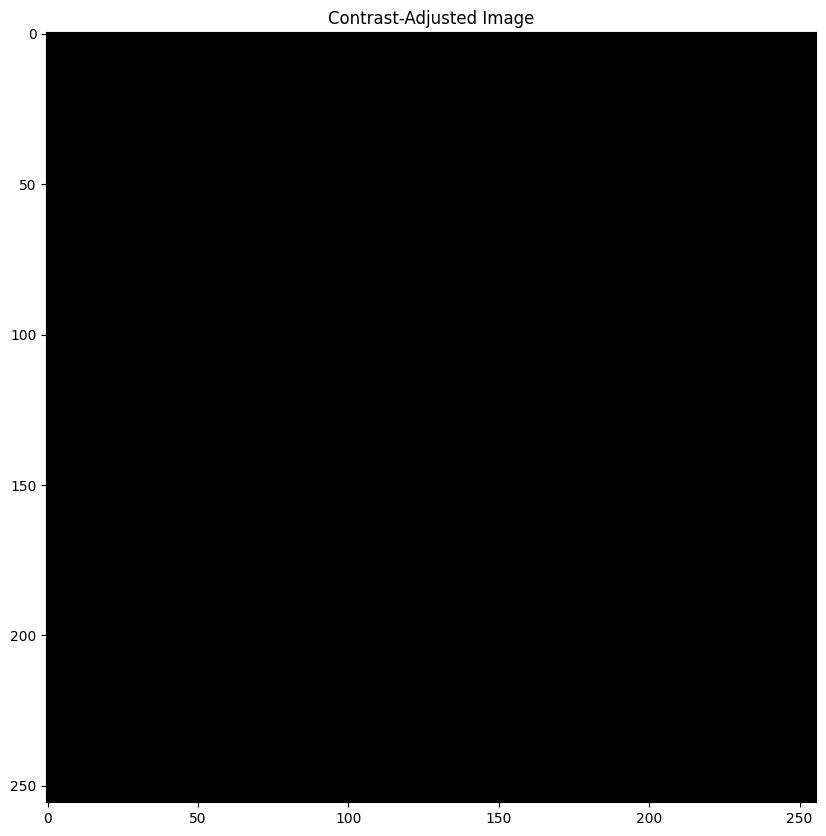

In [343]:
hdf5_path = "EV_brightfield.hdf5"
idx = 0
with h5py.File(hdf5_path, "r") as f:
    image_dataset_size = f["image_patches"].shape[0]
    img = f["image_patches"][idx]
    mask = f["mask_patches"][idx]

from torchvision.transforms.functional import adjust_contrast
a = to_8bit(img)
out = adjust_contrast(torch.Tensor(a).unsqueeze(1),0.8).squeeze(1)
fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(out[0], cmap="gray")
ax.set_title("Contrast-Adjusted Image")
plt.show()

In [313]:
out

tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        ...,

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1., 

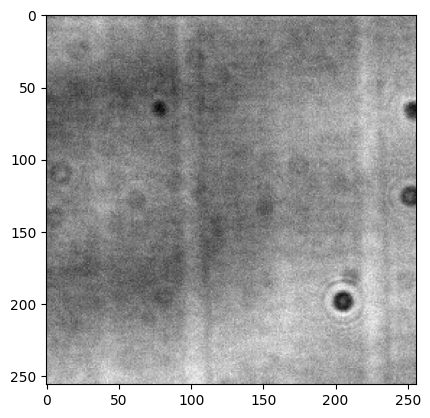

In [315]:
plt.imshow(img[0], cmap="gray")

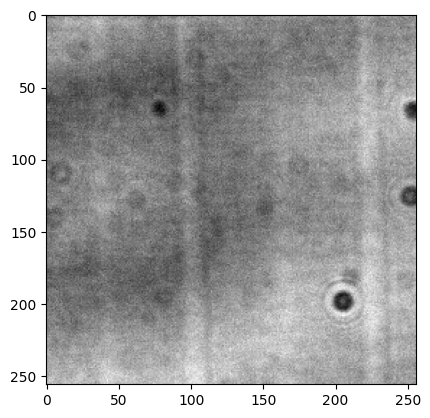

In [344]:
plt.imshow(a[0], cmap="gray")

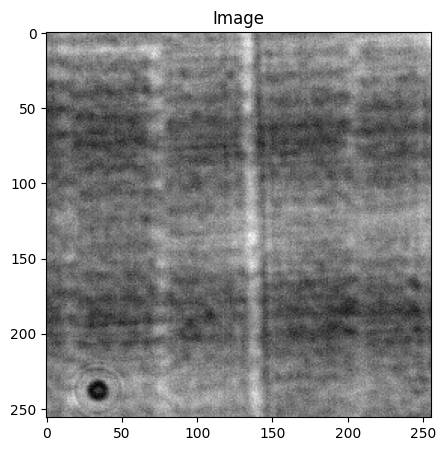

In [257]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.imshow(img[0], cmap="gray")
ax.set_title("Image")
plt.show()